# Mandl: heuristic-rebuild + extend/trim 5+5 — iteration budget sweep

**Цель**: измерить как качество финального решения зависит от бюджета итераций BCO.

| Параметр | Значение |
|---|---|
| Город | Mandl (15 узлов, 6 маршрутов, длина 2–8) |
| Популяция | 10 пчёл: 5 heuristic-rebuild (type-1) + 5 extend/trim edit (type-5) |
| Init | RPC (one-shot construction, аналогично benchmark sweep) |
| Бюджет итераций | 100 / 200 / 300 / 400 |
| `worse_accept` | **OFF** (temperature = 0) |
| `worse_selection` | **OFF** (temperature = 0) |
| Early stopping | **отключён** |

Каждый запуск — один seed (детерминированный RPC init). Выводится кривая сходимости
cost-history и финальная сводная таблица.

In [8]:
import os as _os, sys as _sys
_NB_DIR = _os.path.abspath(".")
if _NB_DIR not in _sys.path:
    _sys.path.insert(0, _NB_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from omegaconf import OmegaConf
from IPython.display import display

import eval_lib
from eval_lib import *  # noqa: F401,F403
from eval_lib import plots as _plots

pd.set_option("display.max_columns", None)
print("eval_lib loaded")

eval_lib loaded


## Конфигурация эксперимента

In [9]:
# --- Параметры эксперимента ---
MANDL_SPEC = next(s for s in BENCHMARK_SPECS if s["city"] == "Mumford3")

N_ITER_GRID = [100, 200, 300, 400]   # бюджеты итераций

N_BEES         = 10
N_TYPE1_BEES   = 5    # heuristic rebuild
N_TYPE5_BEES   = 5    # extend/trim edit

# Cost weights: alpha=1 is demand-only, alpha=0 is route-time-only.
COST_ALPHA = 1.0
COST_WEIGHTS = {
    "demand_time_weight": COST_ALPHA,
    "route_time_weight": 1.0 - COST_ALPHA,
    "median_connectivity_weight": 0.0,
}

# Все worse_* и early_stop — выключены
WORSE_ACCEPT_TEMPERATURE    = 0.0
WORSE_SELECTION_TEMPERATURE = 0.0
EARLY_STOP_PATIENCE         = None

_ALPHA_TAG = str(COST_ALPHA).replace(".", "p")
EXPERIMENT_NAME = f"mandl_heuristic_extend_trim_iter_sweep_a{_ALPHA_TAG}"

print(f"City:     {MANDL_SPEC['city']}")
print(f"Routes:   n={MANDL_SPEC['n_routes']},  "
      f"len [{MANDL_SPEC['min_route_len']}, {MANDL_SPEC['max_route_len']}]")
print(f"BCO:      {N_TYPE1_BEES} heuristic_rebuild  +  "
      f"{N_TYPE5_BEES} extend_trim_edit  (total bees={N_BEES})")
print(f"Iters:    {N_ITER_GRID}")
print(f"Cost:     alpha={COST_ALPHA:g}, weights={COST_WEIGHTS}")
print(f"worse_accept:    OFF  (T={WORSE_ACCEPT_TEMPERATURE})")
print(f"worse_selection: OFF  (T={WORSE_SELECTION_TEMPERATURE})")
print(f"early_stop:      disabled")

City:     Mumford3
Routes:   n=60,  len [12, 25]
BCO:      5 heuristic_rebuild  +  5 extend_trim_edit  (total bees=10)
Iters:    [100, 200, 300, 400]
Cost:     alpha=1, weights={'demand_time_weight': 1.0, 'route_time_weight': 0.0, 'median_connectivity_weight': 0.0}
worse_accept:    OFF  (T=0.0)
worse_selection: OFF  (T=0.0)
early_stop:      disabled


## Загрузка графа и начальных маршрутов

In [10]:
print(f"Loading {MANDL_SPEC['city']} tensors + RPC init routes...")
_mandl_tensors, _mandl_init_routes = load_benchmark_graph(MANDL_SPEC)
print(f"  node_locs:   {tuple(_mandl_tensors['node_locs'].shape)}")
print(f"  street_adj:  {tuple(_mandl_tensors['street_adj'].shape)}")
print(f"  init_routes: {tuple(_mandl_init_routes.shape)}")

# Вычислить стоимость начального маршрута для отображения baseline на графиках
_init_cfg = build_bco_cfg(
    run_name="mandl_init_cost",
    n_routes=MANDL_SPEC["n_routes"],
    min_route_len=MANDL_SPEC["min_route_len"],
    max_route_len=MANDL_SPEC["max_route_len"],
    n_bees=1,
    n_type1_bees=0,
    n_type5_bees=0,
    **COST_WEIGHTS,
    worse_accept_temperature=0.0,
    worse_selection_temperature=0.0,
)
OmegaConf.set_struct(_init_cfg, False)
_init_cfg.n_iterations = 0
_init_run_name, _init_metrics, _, _init_routes_out, _ = run_bco(
    _init_cfg, _mandl_init_routes, tensors=_mandl_tensors)
INIT_COST = float(_init_metrics.get("cost", float("nan")))
print(f"\nInit cost (RPC): {INIT_COST:.4f}")

Loading Mumford3 tensors + RPC init routes...


D:\PythonProjects\connectpt\connectpt\routes_generator\utils.py:313: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1858.)
  out_stats = (final_costs.mean(), final_costs.std(), unserved_demand, all_metrics)


  node_locs:   (127, 2)
  street_adj:  (127, 127)
  init_routes: (1, 60, 25)
[mandl_init_cost] route_selection=uniform-random | bee split: heuristic_rebuild=0 local_endpoint_edit=1 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=1)

Init cost (RPC): 1.3943


## Sweep: варьирование числа итераций

In [ ]:
_rows     = []
_histories = {}   # n_iter -> 1-D numpy array длины (n_iter + 1)

for _n_iter in N_ITER_GRID:
    print(f"\n{'='*50}")
    print(f"n_iterations = {_n_iter}")
    print(f"{'='*50}")

    _cfg = build_bco_cfg(
        run_name=f"mandl_heuristic_trim_iter{_n_iter}",
        n_routes=MANDL_SPEC["n_routes"],
        min_route_len=MANDL_SPEC["min_route_len"],
        max_route_len=MANDL_SPEC["max_route_len"],
        n_bees=N_BEES,
        n_type1_bees=N_TYPE1_BEES,
        n_type5_bees=N_TYPE5_BEES,
        worse_accept_temperature=WORSE_ACCEPT_TEMPERATURE,
        worse_selection_temperature=WORSE_SELECTION_TEMPERATURE,
        early_stop_patience=EARLY_STOP_PATIENCE,
        **COST_WEIGHTS,
    )
    # n_iterations перекрывается после build_bco_cfg, т.к. build_bco_cfg
    # использует BCO_N_ITERATIONS (200) по умолчанию
    OmegaConf.set_struct(_cfg, False)
    _cfg.n_iterations = _n_iter

    _ch_out = {}
    _run_name, _metrics, _unserved, _routes, _mut = run_bco(
        _cfg,
        _mandl_init_routes,
        tensors=_mandl_tensors,
        cost_history_out=_ch_out,
    )

    # history shape: [1, n_iter+1]  (batch_size=1) -> squeeze to 1-D
    _h = _ch_out["history"]
    if hasattr(_h, "numpy"):
        _h = _h.squeeze(0).numpy()
    else:
        _h = np.array(_h).squeeze()
    _histories[_n_iter] = _h

    _row = summarize_run(f"IT={_n_iter}", _metrics, _routes)
    _row["n_iterations"] = _n_iter
    _row["alpha"] = COST_ALPHA
    _row["demand_time_weight"] = COST_WEIGHTS["demand_time_weight"]
    _row["route_time_weight"] = COST_WEIGHTS["route_time_weight"]
    _row["median_connectivity_weight"] = COST_WEIGHTS["median_connectivity_weight"]
    _row["final_cost"]   = float(_metrics.get("cost", float("nan")))
    _rows.append(_row)

    print(f"  final cost = {_row['final_cost']:.4f}  "
          f"  ATT={float(_metrics.get('ATT', float('nan'))):.3f}  "
          f"  d_un={float(_metrics.get('$d_{{un}}$', float('nan'))):.1f}%")

print("\n=== Sweep complete ===")


n_iterations = 100
[mandl_heuristic_trim_iter100] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=5 trim_only=0 trim_then_extend=0 (total=10)
  final cost = 0.4693    ATT=28.628    d_un=nan%

n_iterations = 200
[mandl_heuristic_trim_iter200] route_selection=uniform-random | bee split: heuristic_rebuild=5 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=5 trim_only=0 trim_then_extend=0 (total=10)


## Кривые сходимости

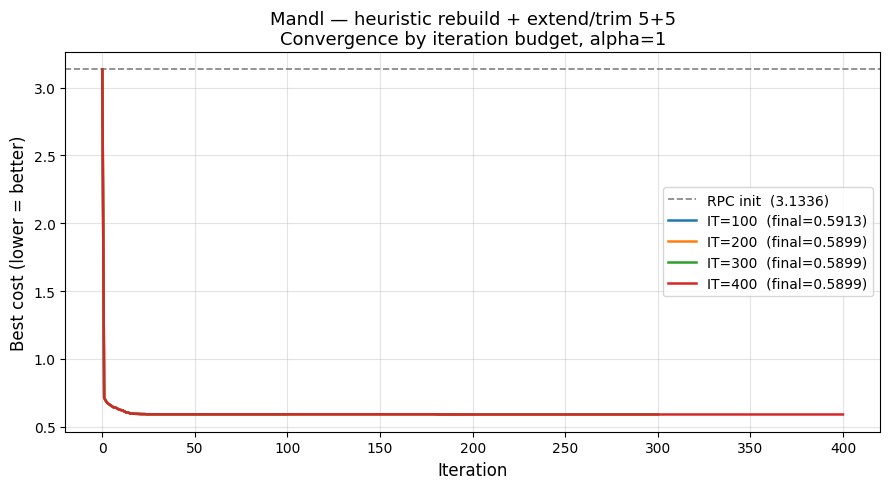

In [ ]:
_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(9, 5))

# baseline: стоимость RPC init
ax.axhline(INIT_COST, color="gray", linestyle="--", linewidth=1.2,
           label=f"RPC init  ({INIT_COST:.4f})")

for _i, _n_iter in enumerate(N_ITER_GRID):
    _h = _histories[_n_iter]
    _x = np.arange(len(_h))
    ax.plot(_x, _h, color=_colors[_i % len(_colors)],
            linewidth=1.8, label=f"IT={_n_iter}  (final={_h[-1]:.4f})")

ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Best cost (lower = better)", fontsize=12)
ax.set_title(
    "Mandl — heuristic rebuild + extend/trim 5+5\n"
    f"Convergence by iteration budget, alpha={COST_ALPHA:g}",
    fontsize=13,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
plt.close(fig)

## Сводная таблица финальных результатов

In [ ]:
_df = pd.DataFrame(_rows)

# выбрать колонки для отображения (connectivity может быть NaN если отключена)
_show_cols = ["n_iterations", "alpha", "final_cost", "ATT", "RTT", "$d_{un}$",
              "# disconnected node pairs", "# routes"]
_show_cols = [c for c in _show_cols if c in _df.columns]

_display_df = _df[_show_cols].round(3)
_display_df = _display_df.sort_values("n_iterations").reset_index(drop=True)

display(_display_df)

# Сохранить полную таблицу в artifacts/results/
save_table(_df.round(3), EXPERIMENT_NAME)
print(f"Saved -> artifacts/results/{EXPERIMENT_NAME}.csv")

,n_iterations,alpha,final_cost,ATT,RTT,$d_{un}$,# disconnected node pairs,# routes
0,100,1.0,0.591,15.373,1294.0,0.0,0.0,12
1,200,1.0,0.590,15.337,1328.0,0.0,0.0,12
2,300,1.0,0.590,15.337,1328.0,0.0,0.0,12
3,400,1.0,0.590,15.337,1328.0,0.0,0.0,12


[results] table (4 rows) -> D:\PythonProjects\connectpt\artifacts\results\mandl_heuristic_extend_trim_iter_sweep_a1p0.csv
Saved -> artifacts/results/mandl_heuristic_extend_trim_iter_sweep_a1p0.csv


## Улучшение относительно init и marginal gain за дополнительные итерации

In [ ]:
_final_costs = {_r["n_iterations"]: _r["final_cost"] for _r in _rows}
_sorted_iters = sorted(_final_costs.keys())

_delta_rows = []
_prev_cost = INIT_COST
_prev_iter = 0
for _it in _sorted_iters:
    _c = _final_costs[_it]
    _delta_rows.append({
        "n_iterations": _it,
        "final_cost": _c,
        "Δ vs init": _c - INIT_COST,
        "Δ vs prev budget": _c - _prev_cost,
        "extra iters": _it - _prev_iter,
        "gain per extra iter": (_prev_cost - _c) / max(_it - _prev_iter, 1),
    })
    _prev_cost = _c
    _prev_iter = _it

_delta_df = pd.DataFrame(_delta_rows).round(5)
display(_delta_df)

,n_iterations,final_cost,Δ vs init,Δ vs prev budget,extra iters,gain per extra iter
0,100,0.59126,-2.54237,-2.54237,100,0.02542
1,200,0.58987,-2.54376,-0.00140,100,0.00001
2,300,0.58987,-2.54376,0.00000,100,0.00000
3,400,0.58987,-2.54376,0.00000,100,0.00000
